In [1]:
import os, glob, warnings, time
import numpy as np
import pandas as pd
import librosa
from joblib import Parallel, delayed
warnings.filterwarnings('ignore')

# ------------------ SETTINGS ------------------
SEED = 42
SR = 16000
MAX_SECONDS_HAND = 40        # audio length used for handcrafted features
USE_PITCH = False            # pitch tracking is slow and adds little; set True to include
USE_W2V = True               # pretrained speech embeddings (needs internet ON in notebook settings)
W2V_MODEL = 'facebook/wav2vec2-base'
W2V_MAX_SECONDS = 20         # lower = faster
W2V_LAYERS = (6, 9, 12)
BATCH = 8                    # clips per forward pass (raise on GPU if memory allows)
WORK = '/kaggle/working'
# ----------------------------------------------
np.random.seed(SEED)
os.makedirs(WORK, exist_ok=True)
print('librosa', librosa.__version__)

librosa 0.11.0


## 1. Load data and sanity-check it

In [2]:
def find_file(name):
    m = sorted(glob.glob(f'/kaggle/input/**/{name}', recursive=True))
    if not m:
        raise FileNotFoundError(f"'{name}' not found under /kaggle/input. Use 'Add Input' to attach the competition.")
    return m[0]

TRAIN_CSV, TEST_CSV, SAMPLE_CSV = find_file('train.csv'), find_file('test.csv'), find_file('sample_submission.csv')
DATA_DIR = os.path.dirname(TRAIN_CSV)
TRAIN_AUDIO_DIR, TEST_AUDIO_DIR = os.path.join(DATA_DIR, 'train'), os.path.join(DATA_DIR, 'test')

train_df, test_df, sample_sub = pd.read_csv(TRAIN_CSV), pd.read_csv(TEST_CSV), pd.read_csv(SAMPLE_CSV)
ID_COL, LABEL_COL = sample_sub.columns[0], sample_sub.columns[1]

print('Data dir     :', DATA_DIR)
print('train / test / sample_submission rows:', len(train_df), len(test_df), len(sample_sub))
print('train columns:', train_df.columns.tolist(), '| test columns:', test_df.columns.tolist())
print('Label stats  :'); print(train_df['label'].describe().round(3).to_string())
print('Test labels: NOT used anywhere in this notebook')

def norm_id(s):
    return os.path.splitext(str(s))[0]

print(f'\nNote: sample_submission has {len(sample_sub)} rows but test.csv has {len(test_df)}; the submission is built from test.csv.')

Data dir     : /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final
train / test / sample_submission rows: 769 216 204
train columns: ['filename', 'label'] | test columns: ['filename', 'label']
Label stats  :
count    769.000
mean       3.313
std        1.239
min        0.000
25%        2.500
50%        3.000
75%        4.000
max        5.000
Test labels: NOT used anywhere in this notebook

Note: sample_submission has 204 rows but test.csv has 216; the submission is built from test.csv.


## 2. Handcrafted features (acoustic + fluency/pause statistics)

In [3]:
def get_audio_path(filename, audio_dir):
    fn = str(filename)
    for c in (fn, fn + '.wav', norm_id(fn) + '.wav'):
        p = os.path.join(audio_dir, c)
        if os.path.exists(p):
            return p
    return None

def _stats(m):
    m = np.atleast_2d(m)
    return list(m.mean(axis=1)) + list(m.std(axis=1))

def hand_features(path, sr=SR, max_seconds=MAX_SECONDS_HAND):
    if path is None:
        return None
    try:
        y, sr = librosa.load(path, sr=sr, duration=max_seconds, res_type='kaiser_fast')
        if len(y) < sr // 2:
            return None
        dur = len(y) / sr
        f = []
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=30)
        f += _stats(mfcc) + _stats(librosa.feature.delta(mfcc)) + _stats(librosa.feature.delta(mfcc, order=2))
        mel = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=sr, n_mels=40))
        f += _stats(mel)
        f += _stats(librosa.feature.spectral_contrast(y=y, sr=sr))
        for fn in (librosa.feature.zero_crossing_rate(y), librosa.feature.rms(y=y),
                   librosa.feature.spectral_centroid(y=y, sr=sr), librosa.feature.spectral_rolloff(y=y, sr=sr),
                   librosa.feature.spectral_bandwidth(y=y, sr=sr), librosa.feature.spectral_flatness(y=y)):
            f += _stats(fn)
        # pitch
        if USE_PITCH:
            f0 = librosa.yin(y, fmin=60, fmax=400, sr=sr, frame_length=1024)
            f0 = f0[(f0 > 60) & (f0 < 399)]
            f += [f0.mean(), f0.std(), np.percentile(f0, 90) - np.percentile(f0, 10)] if len(f0) > 5 else [0, 0, 0]
        # pauses / speech rate proxies
        iv = librosa.effects.split(y, top_db=30)
        speech = sum(e - s for s, e in iv) / sr
        gaps = np.array([(iv[i + 1][0] - iv[i][1]) / sr for i in range(len(iv) - 1)]) if len(iv) > 1 else np.array([0.0])
        long_p = (gaps > 0.3).sum()
        onsets = len(librosa.onset.onset_detect(y=y, sr=sr))
        f += [dur, speech, speech / dur, len(iv), len(iv) / dur, gaps.mean(), gaps.max(), gaps.std(),
              long_p, long_p / dur, onsets, onsets / dur, onsets / max(speech, 1e-3)]
        out = np.nan_to_num(np.array(f, dtype=np.float32), nan=0.0, posinf=0.0, neginf=0.0)
        return out
    except Exception as e:
        print(f'Error processing {path}: {e}')
        return None

def extract_hand(df, audio_dir, tag):
    cache = f'{WORK}/hand_{tag}.npy'
    paths = [get_audio_path(fn, audio_dir) for fn in df['filename']]
    print(f'{tag}: audio files found {sum(p is not None for p in paths)} of {len(paths)}')
    if os.path.exists(cache):
        X = np.load(cache); print(f'{tag}: loaded cached features {X.shape}'); return X, paths
    t = time.time()
    res = Parallel(n_jobs=-1, verbose=0)(delayed(hand_features)(p) for p in paths)
    ok = [r for r in res if r is not None]
    if not ok:
        raise RuntimeError('No audio could be processed - check the audio directory paths above.')
    dim = len(ok[0])
    X = np.stack([r if r is not None else np.full(dim, np.nan, np.float32) for r in res])
    np.save(cache, X); print(f'{tag}: features {X.shape} in {time.time()-t:.0f}s, failed clips: {int(np.isnan(X).all(1).sum())}')
    return X, paths

Xh_train, train_paths = extract_hand(train_df, TRAIN_AUDIO_DIR, 'train')
Xh_test,  test_paths  = extract_hand(test_df,  TEST_AUDIO_DIR,  'test')

train: audio files found 769 of 769
train: features (769, 299) in 152s, failed clips: 0
test: audio files found 216 of 216
test: features (216, 299) in 35s, failed clips: 0


## 3. Pretrained speech embeddings (wav2vec2)
Mean and std pooled hidden states from several layers. If the model cannot be downloaded (no internet), this step is skipped and the notebook continues with handcrafted features only.

In [4]:
def resolve_w2v():
    # 1) a model attached through 'Add Input' (works with Internet OFF)
    for cfg in glob.glob('/kaggle/input/**/config.json', recursive=True):
        d = os.path.dirname(cfg)
        has_w = any(os.path.exists(os.path.join(d, w)) for w in ('model.safetensors', 'pytorch_model.bin'))
        if has_w and 'wav2vec2' in d.lower() and 'large' not in d.lower():
            print('Using attached model:', d); return d
    # 2) download from the Hub (needs Internet ON)
    print('No attached wav2vec2 model found; trying to download', W2V_MODEL)
    return W2V_MODEL

def extract_w2v(paths, tag):
    cache = f'{WORK}/w2v_{tag}.npy'
    if os.path.exists(cache):
        X = np.load(cache); print(f'{tag}: loaded cached embeddings {X.shape}'); return X
    import torch
    from transformers import Wav2Vec2Model
    os.environ.setdefault('HF_HUB_ETAG_TIMEOUT', '10'); os.environ.setdefault('HF_HUB_DOWNLOAD_TIMEOUT', '30')
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    if device == 'cpu':
        torch.set_num_threads(os.cpu_count() or 4)
    print(f'{tag}: running wav2vec2 on {device.upper()}', '(enable a GPU accelerator for a big speed-up)' if device == 'cpu' else '')
    model = Wav2Vec2Model.from_pretrained(W2V_SRC).eval().to(device)
    if device == 'cuda':
        model = model.half()
    # load audio in parallel (cheap), then run the model clip by clip so no padding distorts the pooling
    audio = Parallel(n_jobs=-1)(delayed(lambda p: librosa.load(p, sr=SR, duration=W2V_MAX_SECONDS, res_type='kaiser_fast')[0])(p) for p in paths)
    feats, t = [], time.time()
    for i, y in enumerate(audio):
        try:
            y = (y - y.mean()) / np.sqrt(y.var() + 1e-7)          # same normalisation wav2vec2-base expects
            inp = torch.from_numpy(y.astype(np.float32))[None].to(device)
            if device == 'cuda':
                inp = inp.half()
            with torch.no_grad():
                hs = model(inp, output_hidden_states=True).hidden_states
            v = []
            for l in W2V_LAYERS:
                h = hs[l][0].float()
                v += [h.mean(0).cpu().numpy(), h.std(0).cpu().numpy()]
            feats.append(np.concatenate(v))
        except Exception as e:
            print(f'w2v failed for clip {i}: {e}'); feats.append(None)
        if (i + 1) % 100 == 0:
            print(f'  {tag}: {i+1}/{len(paths)}  ({time.time()-t:.0f}s)')
    dim = next(f for f in feats if f is not None).shape[0]
    X = np.stack([f if f is not None else np.full(dim, np.nan, np.float32) for f in feats]).astype(np.float32)
    np.save(cache, X); return X

Xw_train = Xw_test = None
if USE_W2V:
    try:
        W2V_SRC = resolve_w2v() if not (os.path.exists(f'{WORK}/w2v_train.npy') and os.path.exists(f'{WORK}/w2v_test.npy')) else W2V_MODEL
        Xw_train = extract_w2v(train_paths, 'train')
        Xw_test = extract_w2v(test_paths, 'test')
        print('wav2vec2 features:', Xw_train.shape, Xw_test.shape)
    except Exception as e:
        print('!! wav2vec2 unavailable, continuing with handcrafted features only.')
        print('   Reason:', repr(e)[:300])
        print('   (Attach a wav2vec2-base model via Add Input, or enable Internet, or set USE_W2V = False.)')
        Xw_train = Xw_test = None

No attached wav2vec2 model found; trying to download facebook/wav2vec2-base


train: running wav2vec2 on CUDA 


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

...

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  train: 100/769  (5s)
  train: 200/769  (8s)
  train: 300/769  (11s)
  train: 400/769  (14s)
  train: 500/769  (17s)
  train: 600/769  (20s)
  train: 700/769  (23s)
test: running wav2vec2 on CUDA 


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  test: 100/216  (3s)
  test: 200/216  (6s)
wav2vec2 features: (769, 4608) (216, 4608)


## 4. Cross-validated models and ensemble

In [5]:
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV, LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import HistGradientBoostingRegressor

y = train_df['label'].astype(float).values
ok_tr = ~np.isnan(Xh_train).any(1)
if Xw_train is not None:
    ok_tr &= ~np.isnan(Xw_train).any(1)
print('Usable training clips:', int(ok_tr.sum()), 'of', len(y))
y_fit = y[ok_tr]
Y_MIN, Y_MAX = y_fit.min(), y_fit.max()

def metrics(t, p):
    return dict(RMSE=float(np.sqrt(np.mean((t - p) ** 2))), Pearson=float(pearsonr(t, p)[0]),
                Spearman=float(spearmanr(t, p)[0]), R2=float(1 - np.sum((t - p) ** 2) / np.sum((t - t.mean()) ** 2)))

def svr_cv():
    return GridSearchCV(SVR(kernel='rbf'), {'C': [1, 10], 'epsilon': [0.1], 'gamma': ['scale']},
                        cv=3, scoring='neg_mean_squared_error', n_jobs=-1)

def pipe(est):
    return make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), est)

feature_sets = {'hand': (Xh_train[ok_tr], Xh_test)}
if Xw_train is not None:
    feature_sets['w2v'] = (Xw_train[ok_tr], Xw_test)
    feature_sets['all'] = (np.hstack([Xh_train, Xw_train])[ok_tr], np.hstack([Xh_test, Xw_test]))

models = {
    'ridge_hand': ('hand', lambda: pipe(RidgeCV(alphas=np.logspace(0, 4, 25)))),
    'svr_hand':   ('hand', lambda: pipe(svr_cv())),
    'hgb_hand':   ('hand', lambda: HistGradientBoostingRegressor(max_iter=150, learning_rate=0.06, max_depth=4,
                                                                 l2_regularization=1.0, random_state=SEED)),
}
if 'w2v' in feature_sets:
    models.update({
        'ridge_w2v': ('w2v', lambda: pipe(RidgeCV(alphas=np.logspace(1, 5, 25)))),
        'svr_w2v':   ('w2v', lambda: pipe(svr_cv())),
        'ridge_all': ('all', lambda: pipe(RidgeCV(alphas=np.logspace(1, 5, 25)))),
    })

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
oof = {}
for name, (fs, make) in models.items():
    X = feature_sets[fs][0]; p = np.zeros(len(y_fit)); t = time.time()
    for tr, va in kf.split(X):
        m = make(); m.fit(X[tr], y_fit[tr]); p[va] = m.predict(X[va])
    oof[name] = np.clip(p, Y_MIN, Y_MAX)
    print(f'{name:11s}', {k: round(v, 4) for k, v in metrics(y_fit, oof[name]).items()}, f'({time.time()-t:.0f}s)')

Usable training clips: 769 of 769
ridge_hand  {'RMSE': 0.83, 'Pearson': 0.7425, 'Spearman': 0.6153, 'R2': 0.5507} (0s)
svr_hand    {'RMSE': 0.7587, 'Pearson': 0.7903, 'Spearman': 0.6815, 'R2': 0.6245} (1s)
hgb_hand    {'RMSE': 0.7843, 'Pearson': 0.774, 'Spearman': 0.6492, 'R2': 0.5988} (5s)
ridge_w2v   {'RMSE': 0.6671, 'Pearson': 0.8425, 'Spearman': 0.7663, 'R2': 0.7097} (3s)
svr_w2v     {'RMSE': 0.6615, 'Pearson': 0.8463, 'Spearman': 0.7748, 'R2': 0.7146} (16s)
ridge_all   {'RMSE': 0.651, 'Pearson': 0.8507, 'Spearman': 0.7771, 'R2': 0.7235} (3s)


Blend weights: {'ridge_hand': 0.0, 'svr_hand': 0.248, 'hgb_hand': 0.0, 'ridge_w2v': 0.0, 'svr_w2v': 0.398, 'ridge_all': 0.436} | intercept -0.267
Baseline (predict the mean) RMSE: 1.2382
ENSEMBLE cross-validated: {'RMSE': 0.6339, 'Pearson': 0.8592, 'Spearman': 0.7881, 'R2': 0.7379}


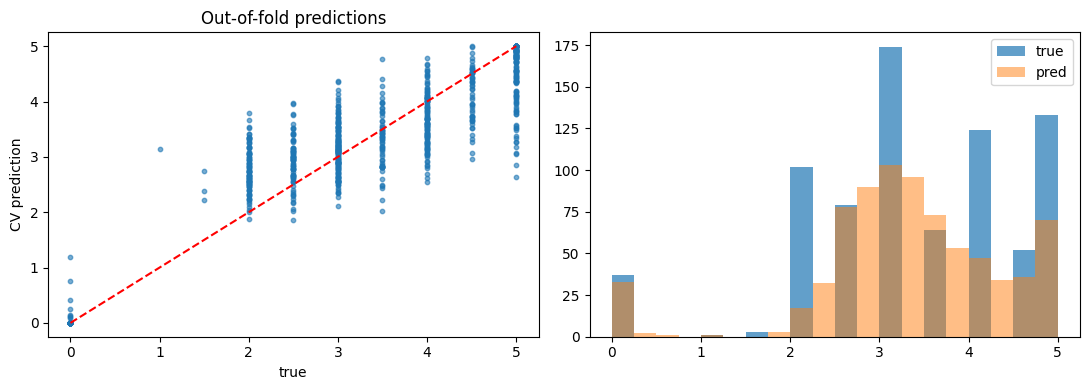

In [6]:
names = list(oof)
S = np.column_stack([oof[n] for n in names])

# Non-negative blend weights; honest estimate of the blend via a second-level CV on the OOF matrix
blend = LinearRegression(positive=True).fit(S, y_fit)
blend_oof = np.zeros(len(y_fit))
for tr, va in KFold(5, shuffle=True, random_state=SEED + 1).split(S):
    blend_oof[va] = LinearRegression(positive=True).fit(S[tr], y_fit[tr]).predict(S[va])
blend_oof = np.clip(blend_oof, Y_MIN, Y_MAX)

print('Blend weights:', {n: round(float(w), 3) for n, w in zip(names, blend.coef_)}, '| intercept', round(float(blend.intercept_), 3))
print('Baseline (predict the mean) RMSE:', round(float(np.sqrt(np.mean((y_fit - y_fit.mean()) ** 2))), 4))
BLEND_M = metrics(y_fit, blend_oof)
print('ENSEMBLE cross-validated:', {k: round(v, 4) for k, v in BLEND_M.items()})

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(y_fit, blend_oof, s=10, alpha=.6); ax[0].plot([Y_MIN, Y_MAX], [Y_MIN, Y_MAX], 'r--')
ax[0].set_xlabel('true'); ax[0].set_ylabel('CV prediction'); ax[0].set_title('Out-of-fold predictions')
ax[1].hist(y_fit, bins=20, alpha=.7, label='true'); ax[1].hist(blend_oof, bins=20, alpha=.5, label='pred'); ax[1].legend()
plt.tight_layout(); plt.show()

## 5. Fit on all training data and predict the test set

In [7]:
test_preds = []
for name in names:
    fs, make = models[name]
    m = make(); m.fit(feature_sets[fs][0], y_fit)
    Xt = feature_sets[fs][1]
    p = np.full(len(Xt), np.nan)
    good = ~np.isnan(Xt).any(1)
    p[good] = m.predict(Xt[good])
    test_preds.append(p)
T = np.column_stack(test_preds)
final = np.clip(blend.predict(np.nan_to_num(T, nan=float(y_fit.mean()))), Y_MIN, Y_MAX)
bad = np.isnan(T).any(1)
final[bad] = float(y_fit.mean())
print(f'Test predictions: {len(final)} (clips that failed feature extraction: {int(bad.sum())})')
print(pd.Series(final).describe().round(3).to_string())

pred_by_id = dict(zip(test_df['filename'].map(norm_id), final))

Test predictions: 216 (clips that failed feature extraction: 0)
count    216.000
mean       3.249
std        0.666
min        1.810
25%        2.800
50%        3.163
75%        3.600
max        5.000


## 6. Build the submission
The submission has one row per clip in `test.csv` (the scorer expects that count). `sample_submission.csv` is only used for the column names.

In [8]:
# The scorer expects one row per test clip (len(test.csv)); sample_submission.csv is stale, so it is used only for column names.
sub = pd.DataFrame({ID_COL: test_df['filename'].values, LABEL_COL: final})
sub.to_csv(f'{WORK}/submission.csv', index=False)

print(f'submission.csv: {sub.shape} | test.csv rows: {len(test_df)} | sample_submission rows (ignored): {len(sample_sub)}')
print(sub.head())
assert len(sub) == len(test_df), 'row count must equal the number of test clips'
assert list(sub.columns) == list(sample_sub.columns[:2])
assert sub[LABEL_COL].notna().all() and sub[ID_COL].is_unique
print('\nFiles in /kaggle/working:', sorted(f for f in os.listdir(WORK) if f.endswith('.csv')))

submission.csv: (216, 2) | test.csv rows: 216 | sample_submission rows (ignored): 204
        filename     label
0  audio_128.wav  3.309224
1  audio_156.wav  4.062788
2   audio_19.wav  4.393904
3  audio_108.wav  2.361380
4  audio_206.wav  2.569714

Files in /kaggle/working: ['submission.csv']
